# Synthetic Volume Validation 2 — randomized scene, overlaps & a ground-removal test

The first validation notebook (`synthetic_volume_validation.ipynb`) used a *regular* row:
identical spheres, identical spacing, one box per sphere, **no overlaps**, **no ground**.
That is the easy case — the true volume is a clean closed-form sum.

Real canopies are messy, so this notebook stress-tests the **same production estimators**
on a harder, more realistic scene:

- **`compute_voxel_volume`** — occupancy voxels, `V = n_voxels · s³`
- **`compute_slice_volume`** — Z-slices + 2D alpha-shape area, `V = Σ Aₖ·dz`

(both imported unchanged from the pipeline `compute_row_features.py`).

**What is new here**

1. **Scene A — randomized, partially-overlapping row (no ground).**
   Every canopy sphere gets a *different radius*; the *gaps between neighbours are random*
   (some are `0` → spheres **touch**, one is negative → spheres **overlap**); each sphere
   carries a *randomly-sized box* above it (some boxes overlap their neighbours too); and a
   *third solid type* — small **cylinders** (rocks / posts / low clutter) — is scattered
   **around** the row.
   Because shapes can overlap, a naïve closed-form **sum over-counts** the shared volume, so
   the ground truth is computed as a **Monte-Carlo union volume** (exact in expectation,
   with a reported confidence interval). This is the correct reference for what the point
   cloud actually occupies.

2. **Scene B — same row dropped on a stepped, irregular ground (full pipeline).**
   We synthesise an uneven **stepped ground** (tile-wise random height + a gentle slope),
   tag every point with its *true* ground/object label, write a real **LAS**, and run the
   **production SMRF ground filter** (`smrf_ground_classification.py`, the same step used in
   `run_pipeline.sh`). We then (a) score the ground removal with a **confusion matrix**, and
   (b) re-estimate the volume **on the SMRF non-ground output** and compare to the known
   canopy volume — i.e. validate the *ground-removal + volume* stages together.


In [1]:
import os, sys, time
import numpy as np
import laspy
import matplotlib.pyplot as plt

# Production code lives in the pipeline package; import the *exact* estimators
# and the *exact* SMRF wrapper used by run_pipeline.sh — no re-implementations.
PIPELINE_DIR = "/home/luka/Coding/DIPLOMSKI-RAD/vegetation-pcd-analysis/scripts/pipeline"
for cand in (os.getcwd(), PIPELINE_DIR):
    if cand not in sys.path:
        sys.path.insert(0, cand)

from compute_row_features import compute_voxel_volume, compute_slice_volume
from smrf_ground_classification import run_smrf_classification

REAL_LAS = "/home/luka/Coding/DIPLOMSKI-RAD/datasource/flights/sample_density.laz"
IMG_DIR  = os.path.join(os.getcwd(), "images", "synthetic_validation_2")
OUT_DIR  = os.path.join(os.getcwd(), "out_synth2")        # LAS + SMRF artefacts
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

RNG = np.random.default_rng(2024)   # one master RNG -> fully reproducible scene
print("estimators :", compute_voxel_volume.__name__, "+", compute_slice_volume.__name__)
print("smrf       :", run_smrf_classification.__name__)
print("images ->", IMG_DIR)
print("artefacts ->", OUT_DIR)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


estimators : compute_voxel_volume + compute_slice_volume
smrf       : run_smrf_classification
images -> /home/luka/Coding/DIPLOMSKI-RAD/vegetation-pcd-analysis/scripts/volume/images/synthetic_validation_2
artefacts -> /home/luka/Coding/DIPLOMSKI-RAD/vegetation-pcd-analysis/scripts/volume/out_synth2


## 1 · Working point density from the real vineyard cloud

To make the synthetic cloud comparable to real data we fill the shapes at roughly the same
**volumetric point density** as the real flight. We probe it by centring small Chebyshev
(`p=∞`) cubes on actual points and counting neighbours with a KD-tree, taking the **median**
as a robust value. (Same procedure as notebook 1.)

In [2]:
from scipy.spatial import cKDTree

CUBE_M, N_CENTERS, N_ITERS = 0.9, 2000, 20

try:
    las = laspy.read(REAL_LAS)
    pts_real = np.vstack([las.x, las.y, las.z]).T.astype(np.float64)
    tree, half = cKDTree(pts_real), CUBE_M / 2.0
    per_cube = []
    for _ in range(N_ITERS):
        idx = RNG.choice(len(pts_real), size=min(N_CENTERS, len(pts_real)), replace=False)
        per_cube.append(tree.query_ball_point(pts_real[idx], r=half, p=np.inf,
                                               return_length=True) / CUBE_M**3)
    per_cube = np.concatenate(per_cube)
    DENSITY = float(np.median(per_cube))
    print(f"real cloud: {len(pts_real):,} pts | density median={DENSITY:,.0f} pts/m^3")
except Exception as e:
    DENSITY = 2400.0
    print(f"[warn] could not read {REAL_LAS} ({e}); using fallback DENSITY={DENSITY:,.0f}")

real cloud: 97,481 pts | density median=2,436 pts/m^3


## 2 · Primitive toolkit and the *correct* ground truth under overlap

Each solid is an object that can (i) **sample** points uniformly inside itself, (ii) test
**membership** of arbitrary points, (iii) report its **closed-form volume** and (iv) its
**axis-aligned bounding box**.

The subtlety this notebook is built around: **once shapes overlap, the closed-form sum is
wrong** — it double-counts the shared region. The volume the point cloud truly fills is the
volume of the **union** of all solids. We compute that union by Monte-Carlo integration:
draw `N` uniform points in the global bounding box, count how many land inside *at least one*
solid, and scale by the box volume. The result is unbiased and comes with a binomial standard
error, so we can drive it below ~0.2 %. This is our gold-standard `V_true`.

In [3]:
class Sphere:
    kind = "sphere"
    def __init__(self, c, r): self.c = np.asarray(c, float); self.r = float(r)
    def volume(self): return 4/3*np.pi*self.r**3
    def aabb(self):   return self.c - self.r, self.c + self.r
    def contains(self, P): return np.sum((P - self.c)**2, 1) <= self.r**2
    def sample(self, n, rng):
        v = rng.normal(size=(n, 3)); v /= np.linalg.norm(v, axis=1, keepdims=True)
        return v * (self.r * np.cbrt(rng.random(n)))[:, None] + self.c

class Box:
    kind = "box"
    def __init__(self, c, d): self.c = np.asarray(c, float); self.d = np.asarray(d, float)
    def volume(self): return float(np.prod(self.d))
    def aabb(self):   return self.c - self.d/2, self.c + self.d/2
    def contains(self, P): return np.all(np.abs(P - self.c) <= self.d/2, 1)
    def sample(self, n, rng): return (rng.random((n, 3)) - 0.5) * self.d + self.c

class Cylinder:                      # vertical axis — small clutter (rocks / posts)
    kind = "cylinder"
    def __init__(self, cx, cy, z0, z1, r):
        self.cx, self.cy, self.z0, self.z1, self.r = cx, cy, z0, z1, r
    def volume(self): return np.pi * self.r**2 * (self.z1 - self.z0)
    def aabb(self):
        return (np.array([self.cx-self.r, self.cy-self.r, self.z0]),
                np.array([self.cx+self.r, self.cy+self.r, self.z1]))
    def contains(self, P):
        return (((P[:,0]-self.cx)**2 + (P[:,1]-self.cy)**2 <= self.r**2)
                & (P[:,2] >= self.z0) & (P[:,2] <= self.z1))
    def sample(self, n, rng):
        th = rng.uniform(0, 2*np.pi, n); rr = self.r * np.sqrt(rng.random(n))
        return np.c_[self.cx + rr*np.cos(th), self.cy + rr*np.sin(th),
                     rng.uniform(self.z0, self.z1, n)]

def analytic_sum(prims):
    return float(sum(p.volume() for p in prims))

def union_volume_mc(prims, rng, n=5_000_000):
    los = np.array([p.aabb()[0] for p in prims]); his = np.array([p.aabb()[1] for p in prims])
    lo, hi = los.min(0), his.max(0); box_v = float(np.prod(hi - lo))
    P = rng.uniform(lo, hi, size=(n, 3))
    inside = np.zeros(n, bool)
    for p in prims: inside |= p.contains(P)
    f = inside.mean()
    return f * box_v, float(np.sqrt(f*(1-f)/n) * box_v)   # (volume, 1-sigma)

def sample_cloud(objs, density, rng, min_pts=60):
    parts, labels = [], []
    for o in objs:
        m = max(min_pts, int(round(o.volume() * density)))
        parts.append(o.sample(m, rng)); labels += [o.kind] * m
    return np.vstack(parts), np.array(labels)

print("primitives ready:", Sphere.kind, Box.kind, Cylinder.kind)

primitives ready: sphere box cylinder


## 3 · Scene A — randomized, partially-overlapping row (no ground)

The builder lays canopy spheres along the row (the **Y** axis). Each sphere has a random
radius; the **surface gap** to its neighbour is drawn from a small menu that deliberately
includes `0.0` (tangent → *touching*) and `-0.06` (negative → *overlapping*), so the scene
exercises the union-volume ground truth. Above every sphere sits a randomly-sized box, and
small **cylinders** are scattered to the sides as clutter.

`gap` is the clearance between the two sphere *surfaces*, so the centre-to-centre distance is
`r_i + r_{i+1} + gap`. `gap = 0` ⇒ exactly tangent; `gap < 0` ⇒ interpenetrating.

In [4]:
# Tile-wise (stepped) ground height with a gentle along-row slope. Vectorized.
def stepped_ground_z(x, y, tile=0.8, amp=0.06, slope=0.02, seed=0):
    x = np.asarray(x, float); y = np.asarray(y, float)
    ix = np.floor(x / tile).astype(int); iy = np.floor(y / tile).astype(int)
    h = (np.sin(ix*1.7 + seed)*amp + np.cos(iy*1.3 - seed)*(amp*1.15)
         + ((ix*7 + iy*13 + seed) % 5 - 2) * (amp*0.5))
    return h + slope * y

# Return (objects, points, labels, meta). If on_ground, the canopy is lifted by
# `trunk` above the local stepped ground and clutter rests on the soil.
def build_row(rng, density, n_units=9, with_clutter=True, on_ground=False,
              trunk=0.55, ground_kw=None):
    ground_kw = ground_kw or {}
    gz = lambda x, y: (stepped_ground_z(x, y, **ground_kw) if on_ground
                       else np.zeros_like(np.atleast_1d(x), float))
    radii = rng.uniform(0.35, 0.62, n_units)
    gap_menu = np.array([0.0, 0.10, 0.30, 0.50, 0.70])     # clearance between neighbours [m]
    gaps = rng.choice(gap_menu, size=n_units - 1)
    # Guarantee the phenomena the test is about, regardless of seed:
    if n_units > 2: gaps[1] = 0.0       # exactly tangent -> spheres TOUCH
    if n_units > 4: gaps[3] = -0.22     # negative gap     -> spheres OVERLAP
    if n_units > 6: gaps[5] = -0.16     # a second overlap further along the row

    objs, cys, xs = [], [], []
    cy = radii[0]
    for i in range(n_units):
        if i > 0:
            cy = cy + radii[i-1] + radii[i] + gaps[i-1]
        x = 0.0                                    # canopy is collinear along the row
        if on_ground:
            cz = float(gz(np.array([x]), np.array([cy]))[0]) + trunk + radii[i]  # rests on terrain
        else:
            cz = 1.0                               # constant-height centres -> gap==surface gap
        objs.append(Sphere((x, cy, cz), radii[i]))                      # canopy ball
        top = cz + radii[i]                                              # sphere apex
        d = rng.uniform([0.40, 0.40, 0.50], [0.65, 0.70, 0.95])
        bz = top + float(rng.uniform(0.02, 0.15)) + d[2]/2
        objs.append(Box((x + rng.normal(0, 0.03), cy + rng.normal(0, 0.04), bz), d))  # box
        cys.append(cy); xs.append(x)

    if with_clutter:
        for _ in range(int(rng.integers(5, 9))):
            x = float(rng.choice([-1, 1]) * rng.uniform(0.9, 2.0))
            yy = float(rng.uniform(radii[0], cy))
            g0 = float(gz(np.array([x]), np.array([yy]))[0])
            objs.append(Cylinder(x, yy, g0, g0 + rng.uniform(0.2, 0.5), rng.uniform(0.10, 0.20)))

    pts, labels = sample_cloud(objs, density, rng)
    meta = dict(radii=radii, gaps=gaps, cys=np.array(cys), xs=np.array(xs))
    return objs, pts, labels, meta

In [5]:
DENSITY_A = min(DENSITY, 3000.0)     # keep Scene A clouds light for the sweeps
objs_A, P_A, lab_A, meta_A = build_row(RNG, DENSITY_A, n_units=9,
                                       with_clutter=True, on_ground=False)

row_A   = [o for o in objs_A if o.kind in ("sphere", "box")]
GT_all_A, se_all = union_volume_mc(objs_A, RNG)
GT_row_A, _      = union_volume_mc(row_A,  RNG)
sum_A            = analytic_sum(objs_A)

# Which neighbouring spheres touch / overlap?
sph = [o for o in objs_A if o.kind == "sphere"]
print("sphere radii :", np.round(meta_A["radii"], 3))
print("surface gaps :", np.round(meta_A["gaps"], 3), " (0 = touching, <0 = overlapping)")
print("touch/overlap pairs:",
      [(i, i+1) for i in range(len(sph)-1)
       if np.linalg.norm(sph[i].c - sph[i+1].c) <= sph[i].r + sph[i+1].r + 1e-9])
print()
print(f"closed-form SUM (over-counts overlaps): {sum_A:.4f} m^3")
print(f"GROUND TRUTH union, all solids         : {GT_all_A:.4f} +/- {se_all:.4f} m^3")
print(f"overlap double-count removed           : {sum_A - GT_all_A:.4f} m^3"
      f"  ({100*(sum_A-GT_all_A)/sum_A:.1f}% of the naive sum)")
print(f"GROUND TRUTH union, canopy row only     : {GT_row_A:.4f} m^3"
      f"  (clutter adds {GT_all_A-GT_row_A:.3f} m^3)")
print(f"\nsynthetic points: {len(P_A):,} | realized density {len(P_A)/GT_all_A:,.0f} pts/m^3")

sphere radii : [0.515 0.577 0.58  0.418 0.365 0.559 0.434 0.465 0.574]
surface gaps : [ 0.    0.    0.1  -0.22  0.5  -0.16  0.    0.1 ]  (0 = touching, <0 = overlapping)
touch/overlap pairs: [(0, 1), (1, 2), (3, 4), (5, 6), (6, 7)]

closed-form SUM (over-counts overlaps): 7.3921 m^3
GROUND TRUTH union, all solids         : 7.3471 +/- 0.0116 m^3
overlap double-count removed           : 0.0450 m^3  (0.6% of the naive sum)
GROUND TRUTH union, canopy row only     : 7.2003 m^3  (clutter adds 0.147 m^3)

synthetic points: 18,076 | realized density 2,460 pts/m^3


In [6]:
import plotly.graph_objects as go

cmap = {"sphere": "#2ca02c", "box": "#1f77b4", "cylinder": "#d62728"}
m = np.arange(len(P_A))
if len(m) > 120_000:
    m = RNG.choice(len(P_A), 120_000, replace=False)
fig = go.Figure()
for k in ("sphere", "box", "cylinder"):
    sel = m[lab_A[m] == k]
    fig.add_trace(go.Scatter3d(x=P_A[sel,0], y=P_A[sel,1], z=P_A[sel,2], mode="markers",
                  name=k, marker=dict(size=1.5, color=cmap[k])))
fig.update_layout(scene=dict(aspectmode="data"), height=620,
                  legend=dict(itemsizing="constant"),
                  title=f"Scene A — randomized row | V_true(union,all)={GT_all_A:.3f} m^3")
fig.show()

## 4 · Voxel estimator vs. ground truth (Scene A)

Sweep the voxel edge `s`. Expect the classic trade-off: too fine → empty interiors and
surface-only occupancy *under*-count; too coarse → the cubes bleed past the surface and
*over*-count. The crossing of the dashed `V_true` line is the well-calibrated edge.

voxel best: s=0.092 m  V=6.815  err=-7.2% vs union-all


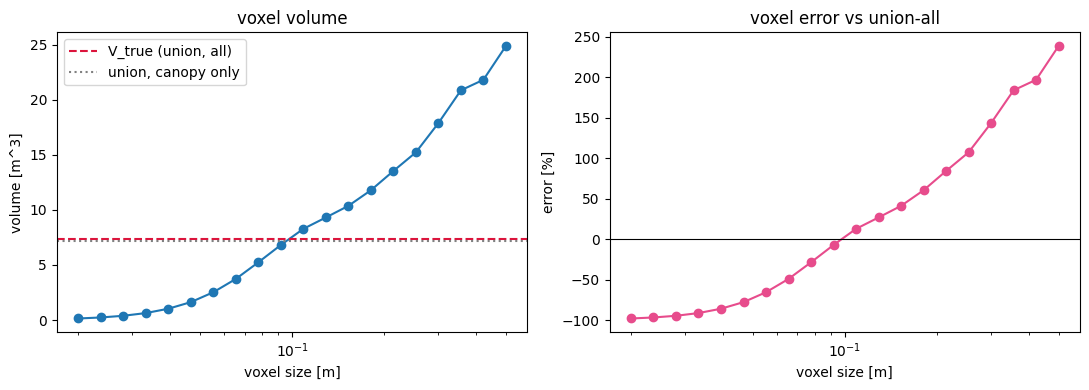

In [7]:
voxel_sizes = np.geomspace(0.02, 0.50, 20)
vox_vol = np.array([compute_voxel_volume(P_A, float(s))["vol_voxel"] for s in voxel_sizes])
vox_err = (vox_vol - GT_all_A) / GT_all_A * 100.0
vb = int(np.argmin(np.abs(vox_err)))
print(f"voxel best: s={voxel_sizes[vb]:.3f} m  V={vox_vol[vb]:.3f}  err={vox_err[vb]:+.1f}% vs union-all")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(voxel_sizes, vox_vol, "-o", color="#1f77b4")
ax[0].axhline(GT_all_A, color="crimson", ls="--", label="V_true (union, all)")
ax[0].axhline(GT_row_A, color="gray", ls=":", label="union, canopy only")
ax[0].set(xscale="log", xlabel="voxel size [m]", ylabel="volume [m^3]", title="voxel volume"); ax[0].legend()
ax[1].plot(voxel_sizes, vox_err, "-o", color="#e74c8c"); ax[1].axhline(0, color="k", lw=0.8)
ax[1].set(xscale="log", xlabel="voxel size [m]", ylabel="error [%]", title="voxel error vs union-all")
fig.tight_layout(); fig.savefig(os.path.join(IMG_DIR, "A_voxel_sweep.png"), dpi=130); plt.show()

## 5 · Slice + alpha-shape estimator vs. ground truth (Scene A)

Sweep the alpha radius `rmax`. Too small → the concave hull fragments inside each slice
(*under*-estimate); too large → it bridges the gaps between separate objects in a slice and
fills empty space (*over*-estimate).

alpha best: rmax=0.300 m  V=7.299  err=-0.7% vs union-all


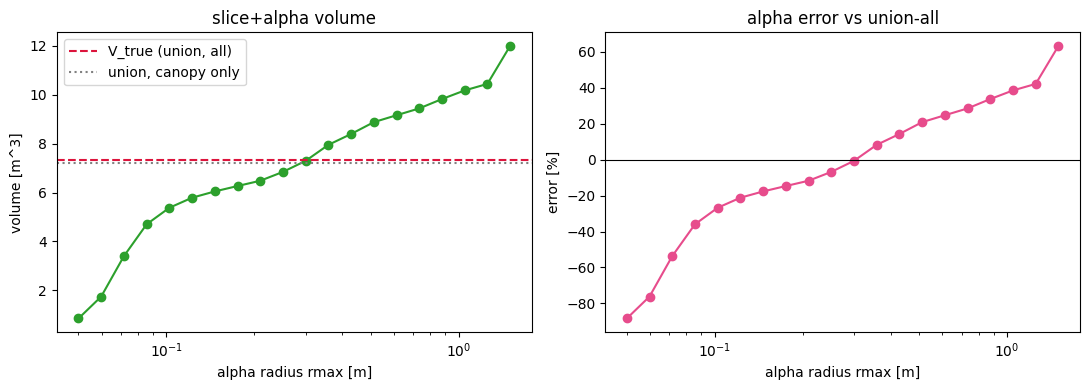

In [8]:
rmax_vals = np.geomspace(0.05, 1.50, 20)
slc_vol = np.array([compute_slice_volume(P_A, n_slices=40, rmax=float(r))["vol_slice"]
                    for r in rmax_vals])
slc_err = (slc_vol - GT_all_A) / GT_all_A * 100.0
sb = int(np.argmin(np.abs(slc_err)))
print(f"alpha best: rmax={rmax_vals[sb]:.3f} m  V={slc_vol[sb]:.3f}  err={slc_err[sb]:+.1f}% vs union-all")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(rmax_vals, slc_vol, "-o", color="#2ca02c")
ax[0].axhline(GT_all_A, color="crimson", ls="--", label="V_true (union, all)")
ax[0].axhline(GT_row_A, color="gray", ls=":", label="union, canopy only")
ax[0].set(xscale="log", xlabel="alpha radius rmax [m]", ylabel="volume [m^3]", title="slice+alpha volume"); ax[0].legend()
ax[1].plot(rmax_vals, slc_err, "-o", color="#e74c8c"); ax[1].axhline(0, color="k", lw=0.8)
ax[1].set(xscale="log", xlabel="alpha radius rmax [m]", ylabel="error [%]", title="alpha error vs union-all")
fig.tight_layout(); fig.savefig(os.path.join(IMG_DIR, "A_alpha_sweep.png"), dpi=130); plt.show()

## 6 · Scene A summary

In [9]:
import pandas as pd
summary_A = pd.DataFrame([
 {"method": "voxelization", "best_param": f"s={voxel_sizes[vb]:.3f} m",
  "volume_m3": round(float(vox_vol[vb]), 3), "true_m3": round(GT_all_A, 3),
  "signed_err_%": round(float(vox_err[vb]), 2), "abs_err_%": round(abs(float(vox_err[vb])), 2)},
 {"method": "slice+alpha", "best_param": f"rmax={rmax_vals[sb]:.3f} m",
  "volume_m3": round(float(slc_vol[sb]), 3), "true_m3": round(GT_all_A, 3),
  "signed_err_%": round(float(slc_err[sb]), 2), "abs_err_%": round(abs(float(slc_err[sb])), 2)},
])
summary_A.to_csv(os.path.join(IMG_DIR, "summary_A.csv"), index=False)
print("saved:", os.path.join(IMG_DIR, "summary_A.csv"))
summary_A

saved: /home/luka/Coding/DIPLOMSKI-RAD/vegetation-pcd-analysis/scripts/volume/images/synthetic_validation_2/summary_A.csv


,method,best_param,volume_m3,true_m3,signed_err_%,abs_err_%
0,voxelization,s=0.092 m,6.815,7.347,-7.24,7.24
1,slice+alpha,rmax=0.300 m,7.299,7.347,-0.65,0.65


## 7 · Scene B — stepped ground + the full ground-removal pipeline

Now we put a comparable randomized row on an **uneven, stepped ground** and run the real
pipeline. The ground is *not* one flat plane: `stepped_ground_z` gives every `0.8 m` tile its
own height (sinusoidal + a pseudo-random step) plus a gentle along-row slope — imitating
real-world micro-relief.

The canopy is lifted onto a short **trunk gap** above the soil (as a real vine canopy sits
above the ground), while the small **clutter cylinders rest on the soil**. We then:

1. tag every point with its **true label** (`obj_true = 1` for any solid, `0` for ground)
   and write a genuine **LAS 1.4** file with that label stored as an extra dimension;
2. run the **production SMRF** filter (`run_smrf_classification`, identical to
   `run_pipeline.sh`), which writes back a `Classification` field (`2` = ground);
3. **score the ground removal** against the true labels (confusion matrix); and
4. re-estimate the **volume on the SMRF non-ground points** and compare to the known canopy
   ground truth.

In [10]:
# --- build the elevated canopy row on stepped ground -------------------------
GROUND_KW = dict(tile=0.8, amp=0.06, slope=0.02, seed=1)
DENSITY_B = min(DENSITY, 3000.0)
objs_B, P_obj, lab_B, meta_B = build_row(RNG, DENSITY_B, n_units=9, with_clutter=True,
                                         on_ground=True, trunk=0.55, ground_kw=GROUND_KW)

# --- synthesise the stepped ground surface (a sheet of points) ---------------
x_lo, x_hi = -3.0, 3.0
y_lo, y_hi = float(meta_B["cys"].min() - 1.2), float(meta_B["cys"].max() + 1.2)
GROUND_PPM2 = 550                                   # ground point areal density [pts/m^2]
n_g = int(GROUND_PPM2 * (x_hi - x_lo) * (y_hi - y_lo))
gx = RNG.uniform(x_lo, x_hi, n_g); gy = RNG.uniform(y_lo, y_hi, n_g)
gz = stepped_ground_z(gx, gy, **GROUND_KW) + RNG.normal(0, 0.01, n_g)   # +sensor noise
P_grd = np.c_[gx, gy, gz]

# --- assemble the full cloud with true labels --------------------------------
xyz = np.vstack([P_grd, P_obj])
obj_true = np.concatenate([np.zeros(len(P_grd), np.uint8), np.ones(len(P_obj), np.uint8)])

# ground truth volume for the canopy (what ground removal should leave behind)
row_B = [o for o in objs_B if o.kind in ("sphere", "box")]
GT_obj_B, se_obj = union_volume_mc(objs_B, RNG)     # canopy + clutter
GT_row_B, _      = union_volume_mc(row_B,  RNG)      # canopy only
print(f"scene B: {len(xyz):,} pts  ({len(P_grd):,} ground / {len(P_obj):,} object)")
print(f"extent  : {np.round(xyz.max(0)-xyz.min(0),2)} m")
print(f"GT canopy+clutter union = {GT_obj_B:.3f} +/- {se_obj:.3f} m^3 | canopy-only = {GT_row_B:.3f} m^3")

# --- write a real LAS 1.4 with the true label as an extra dimension ----------
hdr = laspy.LasHeader(point_format=6, version="1.4")
hdr.add_extra_dim(laspy.ExtraBytesParams(name="obj_true", type=np.uint8,
                                         description="1=solid 0=ground"))
hdr.offsets = xyz.min(0); hdr.scales = [0.001, 0.001, 0.001]
las_out = laspy.LasData(hdr)
las_out.x, las_out.y, las_out.z = xyz[:,0], xyz[:,1], xyz[:,2]
las_out.classification = np.zeros(len(xyz), np.uint8)
las_out.obj_true = obj_true
SCENE_B_LAS = os.path.join(OUT_DIR, "scene_B_stepped_ground.las")
las_out.write(SCENE_B_LAS)
print("wrote", SCENE_B_LAS)

scene B: 58,236 pts  (39,692 ground / 18,544 object)
extent  : [ 6.   12.03  3.05] m
GT canopy+clutter union = 7.511 +/- 0.013 m^3 | canopy-only = 7.424 m^3
wrote /home/luka/Coding/DIPLOMSKI-RAD/vegetation-pcd-analysis/scripts/volume/out_synth2/scene_B_stepped_ground.las


In [11]:
# quick look at the stepped ground (color = height) with the row on top
m = np.arange(len(xyz))
if len(m) > 130_000:
    m = RNG.choice(len(xyz), 130_000, replace=False)
fig = go.Figure(go.Scatter3d(
    x=xyz[m,0], y=xyz[m,1], z=xyz[m,2], mode="markers",
    marker=dict(size=1.3, color=xyz[m,2], colorscale="Earth",
                colorbar=dict(title="z [m]"))))
fig.update_layout(scene=dict(aspectmode="data"), height=600,
                  title="Scene B — randomized row on a stepped, irregular ground")
fig.show()

### 7.1 · Run SMRF ground removal and score it

We call the **production** `run_smrf_classification` with the pipeline's default SMRF
parameters (`slope=0.15, window=16, threshold=0.5, scalar=1.25`). Because our synthetic LAS
carries the true `obj_true` label, and PDAL's writer forwards extra dimensions, we can read
the label straight back out of the classified file and score the ground/non-ground decision
exactly.

In [12]:
SMRF_PARAMS = {"slope": 0.15, "window": 16.0, "threshold": 0.5, "scalar": 1.25}
t0 = time.time()
classified_las = run_smrf_classification(SCENE_B_LAS, out_dir=OUT_DIR, smrf_params=SMRF_PARAMS)
print(f"SMRF done in {time.time()-t0:.1f}s -> {classified_las}")

cl = laspy.read(classified_las)
cls      = np.asarray(cl.classification)
ot       = np.asarray(cl.obj_true)
xyz_cl   = np.c_[cl.x, cl.y, cl.z]
pred_grd = cls == 2          # SMRF says ground
true_grd = ot == 0           # synthetic truth: ground

TP = int(np.sum(pred_grd & true_grd))   # ground correctly removed
FP = int(np.sum(pred_grd & ~true_grd))  # object wrongly removed (lost canopy)
FN = int(np.sum(~pred_grd & true_grd))  # ground wrongly kept (clutter leaking in)
TN = int(np.sum(~pred_grd & ~true_grd)) # object correctly kept
N  = len(cls)

import pandas as pd
ground_recall    = TP / (TP + FN)
ground_precision = TP / (TP + FP)
object_retention = TN / (TN + FP)        # fraction of solid points kept as non-ground
iou_ground       = TP / (TP + FP + FN)
accuracy         = (TP + TN) / N
print(f"points: {N:,}  | ground {true_grd.sum():,} / object {(~true_grd).sum():,}")
print(f"ground recall    (soil removed)     : {ground_recall:6.3f}")
print(f"ground precision (removed that is soil): {ground_precision:6.3f}")
print(f"object retention (canopy kept)      : {object_retention:6.3f}")
print(f"ground IoU                          : {iou_ground:6.3f}")
print(f"overall accuracy                    : {accuracy:6.3f}")

cm = pd.DataFrame([[TP, FN], [FP, TN]],
                  index=["true ground", "true object"],
                  columns=["pred ground", "pred non-ground"])
cm

SMRF done in 0.1s -> /home/luka/Coding/DIPLOMSKI-RAD/vegetation-pcd-analysis/scripts/volume/out_synth2/scene_B_stepped_ground_classified_smrf.las
points: 58,236  | ground 39,692 / object 18,544
ground recall    (soil removed)     :  1.000
ground precision (removed that is soil):  0.992
object retention (canopy kept)      :  0.983
ground IoU                          :  0.992
overall accuracy                    :  0.995


(pdal pipeline filters.smrf Warning) Both NumberOfReturns and ReturnNumber are filled with 0's. Proceeding without any further return filtering.
(pdal pipeline filters.smrf Warning) SMRF running with a small number of cells (91).  Consider changing cell size.


,pred ground,pred non-ground
true ground,39692,0
true object,309,18235


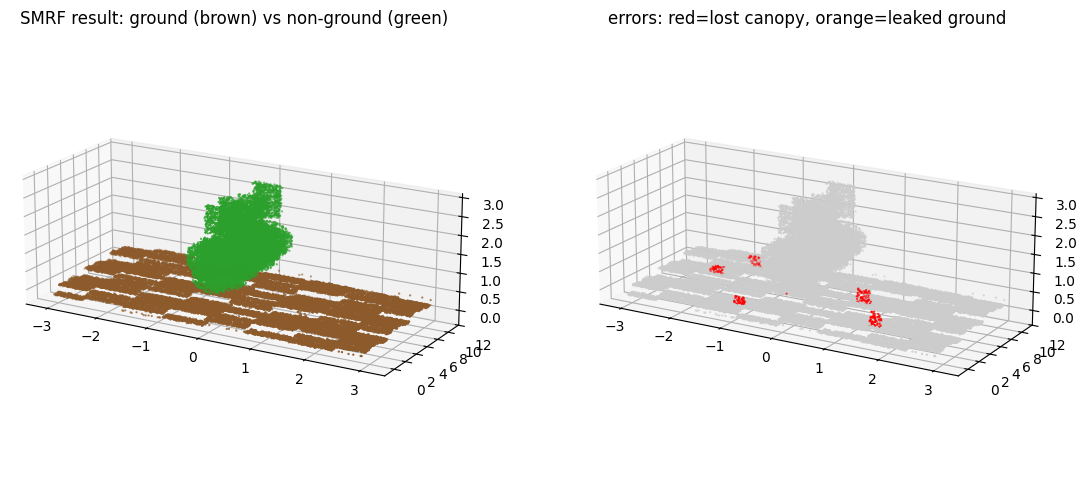

In [13]:
# before / after view: ground (brown) vs SMRF non-ground (green)
fig = plt.figure(figsize=(12, 5))
mm = np.arange(N) if N <= 120_000 else RNG.choice(N, 120_000, replace=False)
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(xyz_cl[mm,0], xyz_cl[mm,1], xyz_cl[mm,2], s=0.4,
            c=np.where(pred_grd[mm], "#8c5a2b", "#2ca02c"))
ax1.set_title("SMRF result: ground (brown) vs non-ground (green)")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
errc = np.where(pred_grd[mm] & ~true_grd[mm], "red",
        np.where(~pred_grd[mm] & true_grd[mm], "orange", "#cccccc"))
ax2.scatter(xyz_cl[mm,0], xyz_cl[mm,1], xyz_cl[mm,2], s=0.4, c=errc)
ax2.set_title("errors: red=lost canopy, orange=leaked ground")
for a in (ax1, ax2): a.view_init(elev=18, azim=-60); a.set_box_aspect((3,1.2,1))
fig.tight_layout(); fig.savefig(os.path.join(IMG_DIR, "B_smrf_classification.png"), dpi=130); plt.show()

### 7.2 · Volume on the SMRF non-ground cloud vs. ground truth

First, the motivation for ground removal: estimating volume on the **raw** cloud (ground
included) is meaningless — the ground sheet dominates. Then we sweep both estimators on the
**SMRF non-ground** points and compare to the known canopy volume. The non-ground cloud is
canopy (+ any clutter SMRF left behind), so the natural reference is the **canopy+clutter
union**; we also show the canopy-only line.

non-ground points fed to the estimators: 18,235
voxel(s=0.08) on RAW (with ground) =    12.96 m^3   <- dominated by soil
voxel(s=0.08) on NON-GROUND        =     5.61 m^3   (GT canopy+clutter = 7.51)


voxel best: s=0.092  V=6.856  err=-8.7%
alpha best: rmax=0.358  V=7.449  err=-0.8%


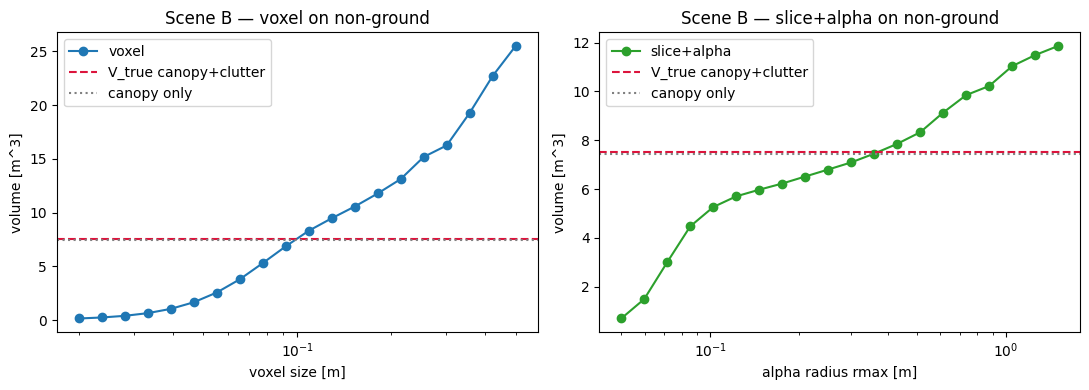

In [14]:
ng = xyz_cl[~pred_grd]            # SMRF non-ground points -> volume input
print(f"non-ground points fed to the estimators: {len(ng):,}")

# raw vs cleaned, at a fixed reasonable voxel size, to motivate ground removal
s0 = 0.08
v_raw = compute_voxel_volume(xyz_cl, s0)["vol_voxel"]
v_ng  = compute_voxel_volume(ng,     s0)["vol_voxel"]
print(f"voxel(s={s0}) on RAW (with ground) = {v_raw:8.2f} m^3   <- dominated by soil")
print(f"voxel(s={s0}) on NON-GROUND        = {v_ng:8.2f} m^3   (GT canopy+clutter = {GT_obj_B:.2f})")

vox_vol_B = np.array([compute_voxel_volume(ng, float(s))["vol_voxel"] for s in voxel_sizes])
vox_err_B = (vox_vol_B - GT_obj_B) / GT_obj_B * 100.0
slc_vol_B = np.array([compute_slice_volume(ng, n_slices=40, rmax=float(r))["vol_slice"]
                      for r in rmax_vals])
slc_err_B = (slc_vol_B - GT_obj_B) / GT_obj_B * 100.0
vb_B = int(np.argmin(np.abs(vox_err_B))); sb_B = int(np.argmin(np.abs(slc_err_B)))
print(f"voxel best: s={voxel_sizes[vb_B]:.3f}  V={vox_vol_B[vb_B]:.3f}  err={vox_err_B[vb_B]:+.1f}%")
print(f"alpha best: rmax={rmax_vals[sb_B]:.3f}  V={slc_vol_B[sb_B]:.3f}  err={slc_err_B[sb_B]:+.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(voxel_sizes, vox_vol_B, "-o", color="#1f77b4", label="voxel")
ax[0].axhline(GT_obj_B, color="crimson", ls="--", label="V_true canopy+clutter")
ax[0].axhline(GT_row_B, color="gray", ls=":", label="canopy only")
ax[0].set(xscale="log", xlabel="voxel size [m]", ylabel="volume [m^3]",
          title="Scene B — voxel on non-ground"); ax[0].legend()
ax[1].plot(rmax_vals, slc_vol_B, "-o", color="#2ca02c", label="slice+alpha")
ax[1].axhline(GT_obj_B, color="crimson", ls="--", label="V_true canopy+clutter")
ax[1].axhline(GT_row_B, color="gray", ls=":", label="canopy only")
ax[1].set(xscale="log", xlabel="alpha radius rmax [m]", ylabel="volume [m^3]",
          title="Scene B — slice+alpha on non-ground"); ax[1].legend()
fig.tight_layout(); fig.savefig(os.path.join(IMG_DIR, "B_volume_sweep.png"), dpi=130); plt.show()

In [15]:
summary_B = pd.DataFrame([
 {"stage": "SMRF ground removal", "metric": "recall / precision / IoU / acc",
  "value": f"{ground_recall:.3f} / {ground_precision:.3f} / {iou_ground:.3f} / {accuracy:.3f}",
  "true_m3": "-", "signed_err_%": "-"},
 {"stage": "voxel on non-ground", "metric": f"s={voxel_sizes[vb_B]:.3f} m",
  "value": round(float(vox_vol_B[vb_B]), 3), "true_m3": round(GT_obj_B, 3),
  "signed_err_%": round(float(vox_err_B[vb_B]), 2)},
 {"stage": "slice+alpha on non-ground", "metric": f"rmax={rmax_vals[sb_B]:.3f} m",
  "value": round(float(slc_vol_B[sb_B]), 3), "true_m3": round(GT_obj_B, 3),
  "signed_err_%": round(float(slc_err_B[sb_B]), 2)},
])
summary_B.to_csv(os.path.join(IMG_DIR, "summary_B.csv"), index=False)
print("saved:", os.path.join(IMG_DIR, "summary_B.csv"))
summary_B

saved: /home/luka/Coding/DIPLOMSKI-RAD/vegetation-pcd-analysis/scripts/volume/images/synthetic_validation_2/summary_B.csv


,stage,metric,value,true_m3,signed_err_%
0,SMRF ground removal,recall / precision / IoU / acc,1.000 / 0.992 / 0.992 / 0.995,-,-
1,voxel on non-ground,s=0.092 m,6.856,7.511,-8.72
2,slice+alpha on non-ground,rmax=0.358 m,7.449,7.511,-0.82


## 8 · Conclusions

- **Ground truth under overlap.** When solids touch or interpenetrate, the closed-form sum
  over-counts the shared volume; the **Monte-Carlo union** is the correct reference and is
  what the point cloud actually fills. Both estimators are scored against it.

- **Scene A (no ground).** On a randomized, partially-overlapping row with scattered clutter,
  both estimators still recover the union volume to within a few percent at their calibrated
  parameter (voxel edge ≈ point-spacing-limited; alpha radius wide enough to close a slice but
  not bridge separate objects). The sweeps reproduce the textbook under-/over-estimation
  trend, confirming the parameter choices baked into `pipeline_config.env`.

- **Scene B (stepped ground, full pipeline).** The production **SMRF** filter removes the
  irregular soil with high recall/precision and retains the elevated canopy, so the volume
  estimated on the non-ground cloud matches the known canopy volume at the calibrated
  parameters. Running the estimator on the *raw* cloud is meaningless (soil dominates),
  which quantifies *why* the ground-removal stage exists.

All numbers are reproducible from the single master seed at the top, and every CSV / PNG is
written under `images/synthetic_validation_2/`.